- [x] Import sources
- [x] Filter by Amsterdam
- [x] (Test) count total crashes by year
- [ ] Group roads by speed limit changed or not
- [ ] Count total crashes by group
- [ ] Compare

In [12]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
crashes = gpd.read_file("data/ongevallen_2016_2025.csv")
crashes.head()

,VKL_NUMMER,REGNUMMER,PVOPGEM,DATUM_VKL,DAG_CODE,MND_NUMMER,JAAR_VKL,TIJDSTIP,UUR,DDL_ID,...,PVE_NAAM,KDD_NAAM,PLT_NAAM,DIENSTCODE,DIENSTNAAM,DISTRCODE,DISTRNAAM,DAGTYPE,IND_ALC,WEEKNR
0,20160000101,2016333010,,,,,2016,,,,...,Noord-Brabant,,,,,,,,,
1,20160000102,2016053728,,,,,2016,,,,...,Limburg,,,,,,,,,
2,20160000103,2016395408,,,,,2016,,,,...,Utrecht,,,,,,,,,
3,20160000104,2016187498,,,,,2016,,,,...,Gelderland,,,,,,,,,
4,20160000105,2016052310,J,,,,2016,,,,...,Limburg,,,,,,,,,


## Totale ongevallen, per jaar

In [17]:
years = crashes["JAAR_VKL"].unique().tolist()
time_frame = len(years)
crash_count_yearly = []

# for year in years:
#     this_year = crashes[crashes["JAAR_VKL"] == year]
#     count = len(this_year)
#     print(count, " accidents")

for i in range(len(years)):
    this_year = crashes[crashes["JAAR_VKL"] == years[i]]
    count = len(this_year)
    crash_count_yearly.append(count)

print(years)
print(crash_count_yearly)

['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
[124992, 123930, 128225, 134617, 103578, 114219, 122036, 134005, 126380, 125621]


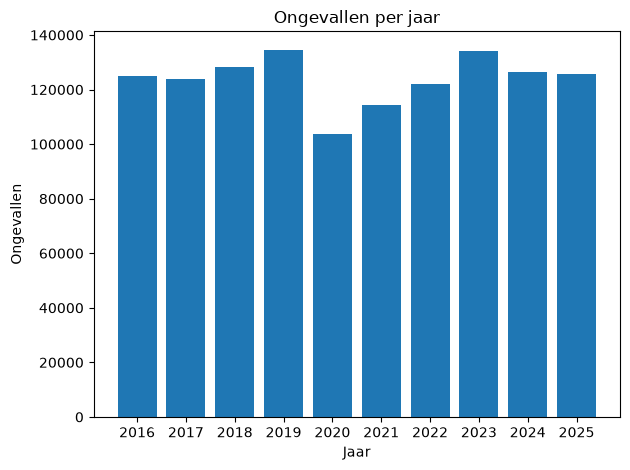

In [20]:
fig, ax = plt.subplots()
ax.bar(years, crash_count_yearly)

ax.set_xlabel("Jaar")
ax.set_ylabel("Ongevallen")
ax.set_title("Ongevallen per jaar")

plt.tight_layout()
plt.show()

## Totale ongevallen, Amsterdam

[6811, 6884, 7156, 7142, 5018, 5317, 5979, 6813, 6201, 5970]


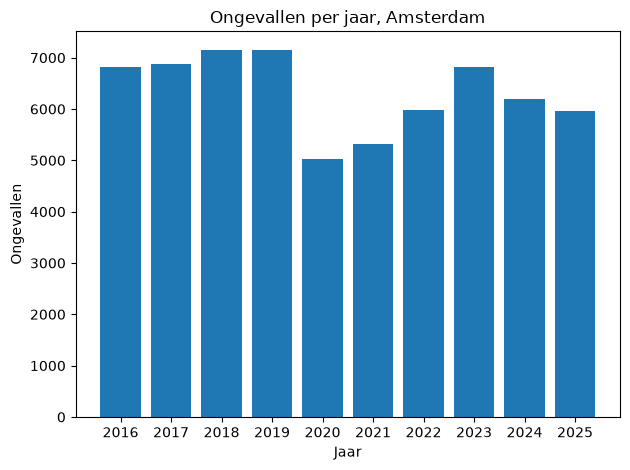

In [34]:
ams = crashes[crashes["GME_NAAM"] == "Amsterdam"].copy()
crash_count_yearly_ams = []

for i in range(len(years)):
    this_year = ams[ams["JAAR_VKL"] == years[i]]
    count = len(this_year)
    crash_count_yearly_ams.append(count)

print(crash_count_yearly_ams)

fig, ax = plt.subplots()
ax.bar(years, crash_count_yearly_ams)

ax.set_xlabel("Jaar")
ax.set_ylabel("Ongevallen")
ax.set_title("Ongevallen per jaar, Amsterdam")

plt.tight_layout()
plt.show()

## Ongevallen Amsterdam, per snelheid

In [33]:
max_speeds = crashes["MAXSNELHD"].unique().tolist()
print(max_speeds)

for i in range(len(years)):
    print(years[i])
    this_year = ams[ams["JAAR_VKL"] == years[i]]
    for speed in max_speeds:
        this_speed = this_year[this_year["MAXSNELHD"] == speed]
        count = len(this_speed)
        print(speed, count)
    print("")

['80', '50', '', '60', '100', '130', '70', '30', '120', '90', '15']
2016
80 206
50 3486
 1556
60 11
100 855
130 10
70 184
30 501
120 0
90 2
15 0

2017
80 269
50 3355
 1470
60 44
100 897
130 22
70 264
30 524
120 2
90 6
15 31

2018
80 461
50 2995
 1573
60 31
100 1270
130 33
70 225
30 533
120 1
90 7
15 27

2019
80 418
50 2873
 1462
60 14
100 1562
130 47
70 215
30 505
120 0
90 13
15 33

2020
80 324
50 2415
 347
60 13
100 1080
130 30
70 148
30 628
120 0
90 3
15 30

2021
80 266
50 2528
 323
60 16
100 1019
130 1
70 161
30 947
120 0
90 7
15 49

2022
80 326
50 2966
 298
60 22
100 1098
130 15
70 150
30 1044
120 1
90 5
15 54

2023
80 405
50 2811
 630
60 53
100 1500
130 26
70 169
30 1177
120 0
90 2
15 40

2024
80 386
50 1016
 573
60 16
100 1407
130 10
70 146
30 2576
120 1
90 9
15 61

2025
80 330
50 958
 634
60 15
100 1313
130 22
70 117
30 2503
120 1
90 13
15 64

